# Norwegian Electricity Prices — Regional Divergence, Volatility & Forecasting (2021–2024)

**Goal:** Analyze real day-ahead electricity spot prices across Norway's 5 price zones through the 2021-2023
energy crisis — quantify the well-known but rarely measured **north/south price gap**, find distinct market
*regimes* with clustering, and build a genuine short-term forecasting model with an honest evaluation.

**Data source:** Daily average day-ahead spot prices (NOK/kWh) for Norway's 5 price zones (NO1–NO5), originally
from **Nord Pool** (the Nordic power exchange), aggregated and maintained by statistician Martin Jullum's open
[`stromstotte`](https://github.com/martinju/stromstotte) project — built to help Norwegians estimate the
government's electricity subsidy ("strømstøtte"). Covers **2021-11-01 to 2024-10-15** (1,080 days × 5 zones,
5,400 rows, no missing values).

**Price zones:** NO1 (Sørøst-Norge/Oslo), NO2 (Sørvest-Norge/Kristiansand), NO3 (Midt-Norge/Trondheim),
NO4 (Nord-Norge/Tromsø), NO5 (Vestlandet/Bergen).

---
### Contents
1. [Data loading & cleaning](#1)
2. [The price crisis, zone by zone](#2)
3. [The north/south divide, quantified](#3)
4. [How correlated are the zones?](#4)
5. [Volatility over time](#5)
6. [Market regimes: clustering days, not zones](#6)
7. [Forecasting: a short-term price model](#7)
8. [Key insights & recommendations](#8)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#008300", "#e34948"]
ZONE_COLOR = {"NO1": CATEGORICAL[0], "NO2": CATEGORICAL[1], "NO3": CATEGORICAL[2],
              "NO4": CATEGORICAL[3], "NO5": CATEGORICAL[4]}
ZONE_ORDER = ["NO1", "NO2", "NO3", "NO4", "NO5"]


<a id="1"></a>\n## 1. Data loading & cleaning

In [2]:
df = pd.read_csv("../data/nordpool_daily_prices_2021_2024.csv", parse_dates=["date"])
print(f"Rows: {df.shape[0]:,}  |  Zones: {sorted(df['area'].unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("Missing values:", df.isna().sum().sum())
df.head()


Rows: 5,400  |  Zones: ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
Date range: 2021-11-01 to 2024-10-15
Missing values: 0


,area,date,price
0,NO1,2021-11-01,0.851175
1,NO2,2021-11-01,0.851175
2,NO3,2021-11-01,0.159513
3,NO4,2021-11-01,0.133320
4,NO5,2021-11-01,0.851175


In [3]:
wide = df.pivot(index="date", columns="area", values="price")[ZONE_ORDER]
wide.describe()


area,NO1,NO2,NO3,NO4,NO5
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,1.399165,1.569917,0.525471,0.314640,1.399909
std,1.163871,1.233398,0.582697,0.318229,1.156282
min,-0.096181,-0.049043,-0.051696,-0.032720,-0.066846
25%,0.599687,0.769546,0.179770,0.132212,0.612188
50%,1.198315,1.240402,0.354024,0.233172,1.212271
75%,1.889881,1.909803,0.696419,0.402066,1.863999
max,8.065762,8.065762,5.805922,3.227436,8.065762


<a id="2"></a>\n## 2. The price crisis, zone by zone

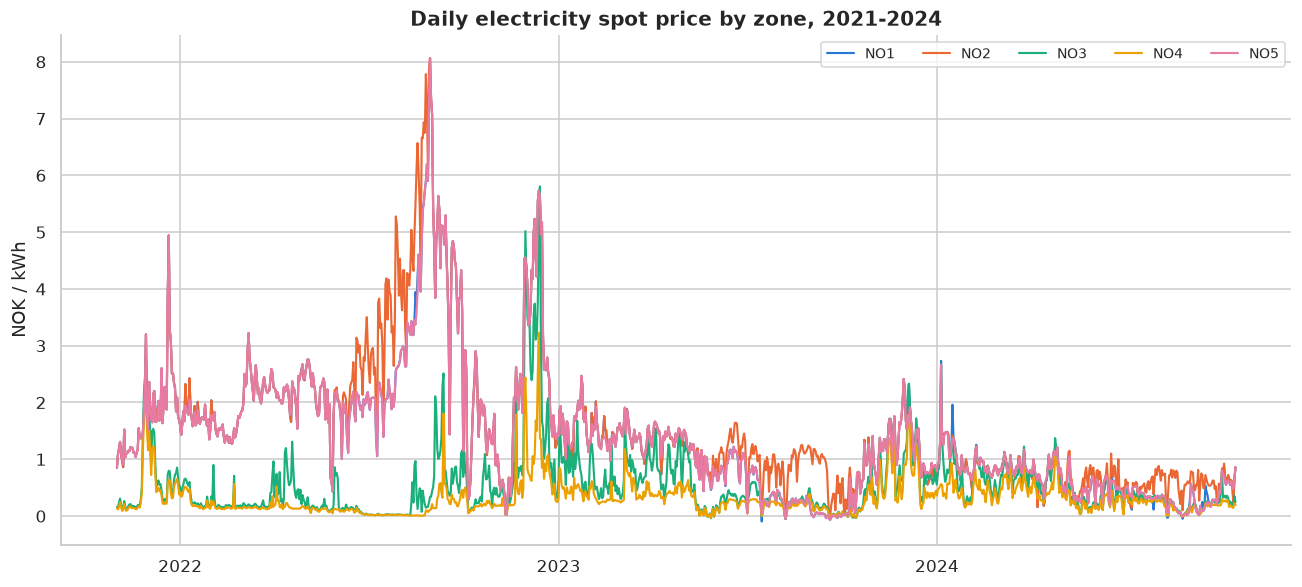

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for zone in ZONE_ORDER:
    ax.plot(wide.index, wide[zone], color=ZONE_COLOR[zone], linewidth=1.4, label=zone)
ax.set_title("Daily electricity spot price by zone, 2021-2024")
ax.set_ylabel("NOK / kWh")
ax.legend(loc="upper right", ncol=5, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("../images/01_price_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()


The southern zones (NO1, NO2, NO5) spike dramatically through 2022 — the well-documented Norwegian/European
energy crisis — while NO3 (mid) and especially **NO4 (north) barely move at all**. That's not a data artifact:
northern Norway is hydro-rich and largely decoupled from the continental European grid that drove southern prices
up via cable interconnectors.


<a id="3"></a>\n## 3. The north/south divide, quantified

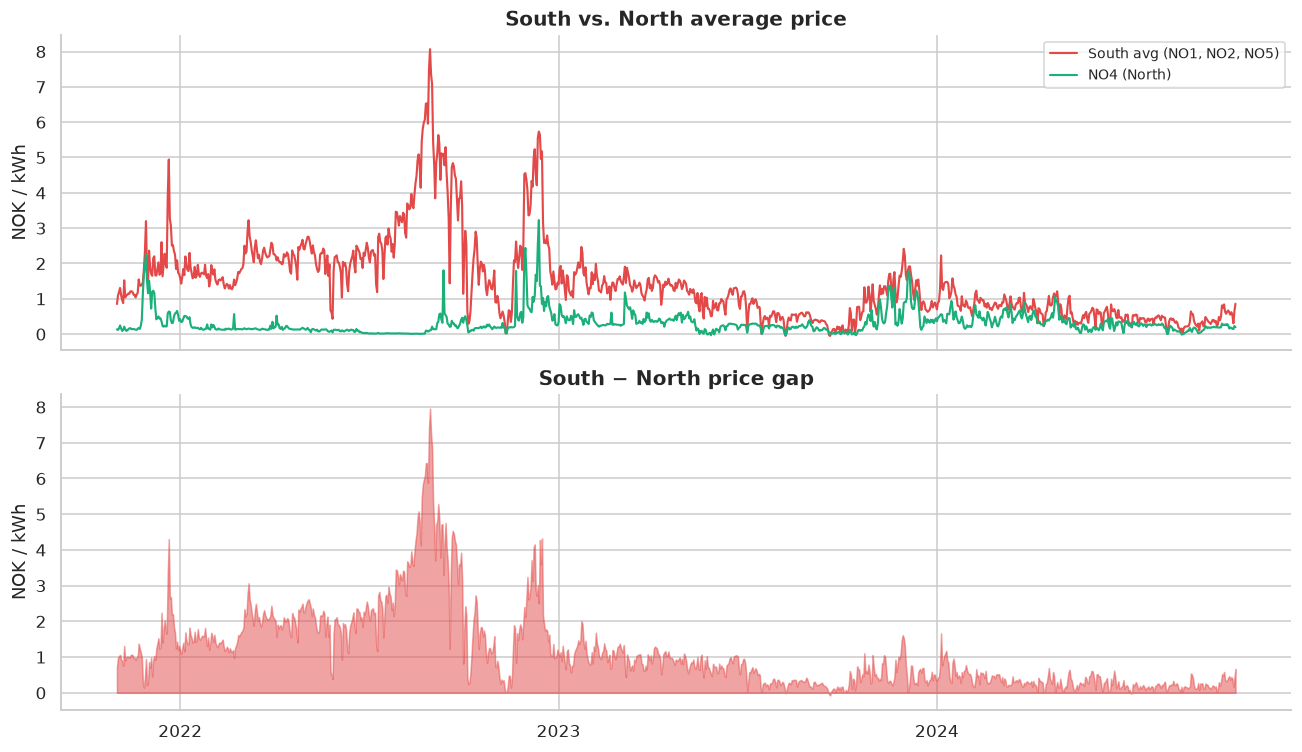

Largest single-day gap: 7.96 NOK/kWh, on 2022-08-30
Mean gap 2022 (crisis year): 2.25 NOK/kWh
Mean gap 2024 (partial):     0.31 NOK/kWh


In [5]:
south_avg = wide[["NO1", "NO2", "NO5"]].mean(axis=1)
gap = south_avg - wide["NO4"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wide.index, south_avg, color=CATEGORICAL[7], linewidth=1.4, label="South avg (NO1, NO2, NO5)")
axes[0].plot(wide.index, wide["NO4"], color=CATEGORICAL[2], linewidth=1.4, label="NO4 (North)")
axes[0].set_ylabel("NOK / kWh")
axes[0].set_title("South vs. North average price")
axes[0].legend(fontsize=9)

axes[1].fill_between(wide.index, gap, color=CATEGORICAL[7], alpha=0.5)
axes[1].set_title("South \u2212 North price gap")
axes[1].set_ylabel("NOK / kWh")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../images/02_north_south_gap.png", dpi=150, bbox_inches="tight")
plt.show()

peak_date = gap.idxmax()
print(f"Largest single-day gap: {gap.max():.2f} NOK/kWh, on {peak_date.date()}")
print(f"Mean gap 2022 (crisis year): {gap.loc['2022'].mean():.2f} NOK/kWh")
print(f"Mean gap 2024 (partial):     {gap.loc['2024'].mean():.2f} NOK/kWh")


<a id="4"></a>\n## 4. How correlated are the zones?\n\nIf the price zones traded as one market, they'd move in lockstep. The correlation matrix shows how much that's actually true — and where the grid effectively splits into separate markets.

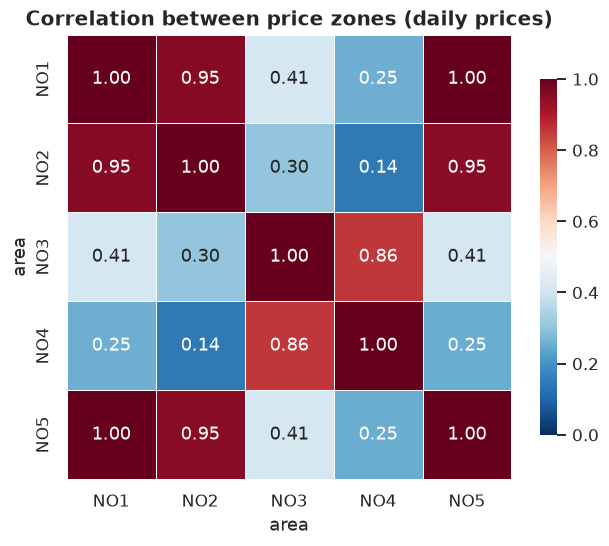

In [6]:
corr = wide.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=0, vmax=1, center=0.5,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation between price zones (daily prices)")
plt.tight_layout()
plt.savefig("../images/03_zone_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


NO1, NO2, and NO5 correlate almost perfectly with each other (they're tightly coupled through the southern grid
and shared exposure to European gas/electricity prices), while **NO4 correlates far more weakly with all of
them** — numerically confirming what the price chart already suggested: the north effectively trades in a
different market than the south.


<a id="5"></a>\n## 5. Volatility over time\n\nAverage price hides how *unpredictable* a market was. A 30-day rolling standard deviation shows when each zone was calm versus turbulent — useful for anyone (a household, a business, a policymaker) thinking about price risk, not just price level.

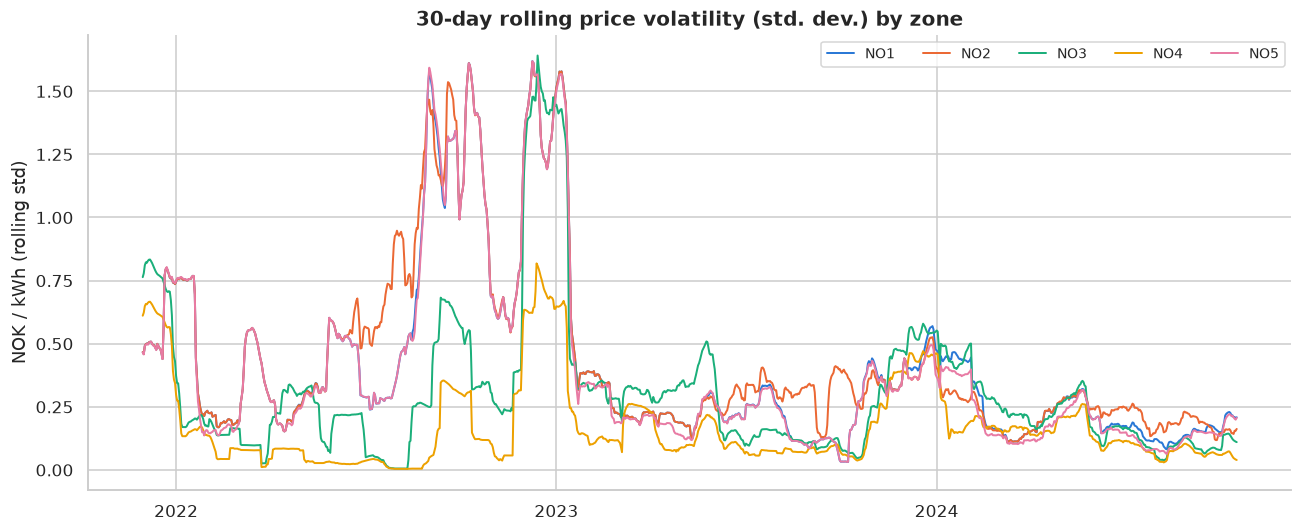

In [7]:
rolling_std = wide.rolling(30).std()

fig, ax = plt.subplots(figsize=(12, 5))
for zone in ZONE_ORDER:
    ax.plot(rolling_std.index, rolling_std[zone], color=ZONE_COLOR[zone], linewidth=1.3, label=zone)
ax.set_title("30-day rolling price volatility (std. dev.) by zone")
ax.set_ylabel("NOK / kWh (rolling std)")
ax.legend(ncol=5, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("../images/04_rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="6"></a>\n## 6. Market regimes: clustering days, not zones\n\nRather than clustering the 5 zones, we cluster **each day** by its 5-zone price *pattern* (standardized) to find distinct market regimes the price level alone doesn't name — e.g. \"calm and uniform\" vs. \"crisis: high and volatile in the south, flat in the north.\"

In [8]:
X = wide.dropna().values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
regime = pd.Series(kmeans.labels_, index=wide.dropna().index, name="regime")

regime_means = wide.dropna().groupby(regime).mean()
print("Average price (NOK/kWh) by regime and zone:")
regime_means.round(2)


Average price (NOK/kWh) by regime and zone:


area,NO1,NO2,NO3,NO4,NO5
regime,,,,,
0,1.86,1.99,0.61,0.37,1.85
1,0.60,0.79,0.32,0.23,0.61
2,4.69,4.99,1.59,0.67,4.68


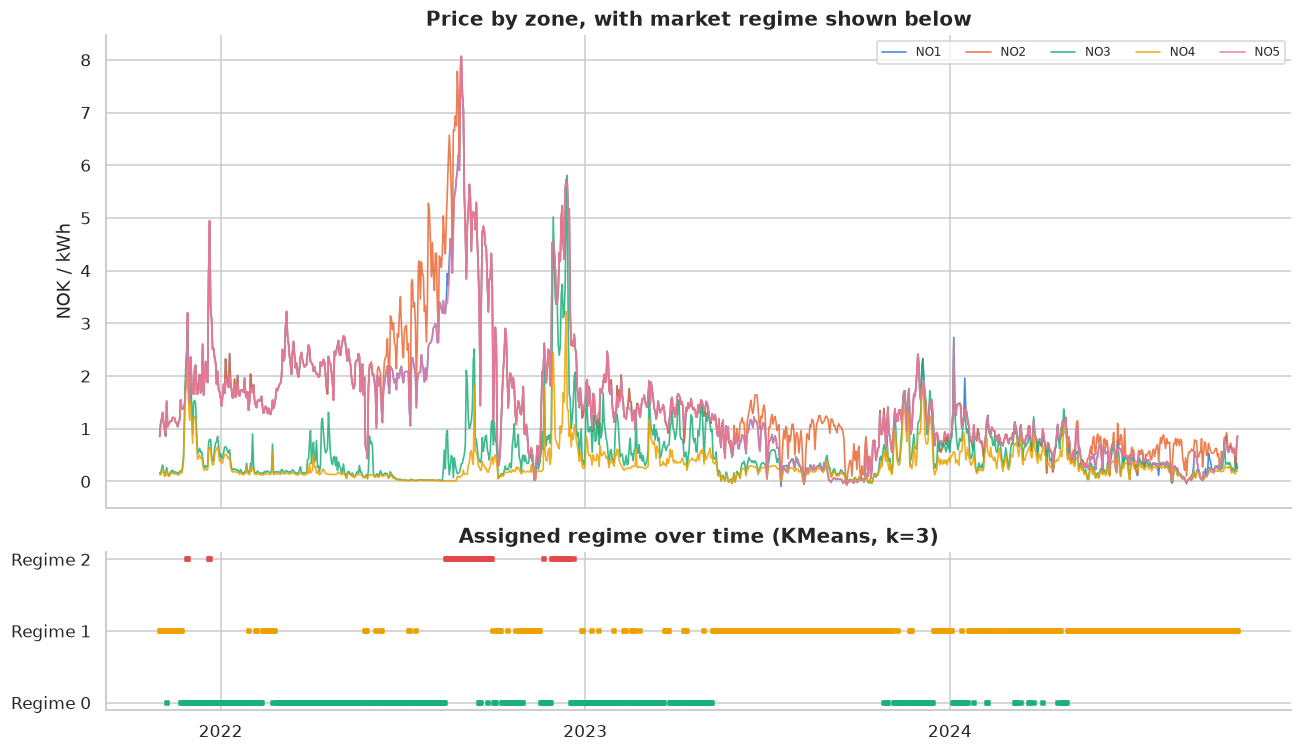

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

for zone in ZONE_ORDER:
    axes[0].plot(wide.index, wide[zone], color=ZONE_COLOR[zone], linewidth=1.1, label=zone, alpha=0.85)
axes[0].set_title("Price by zone, with market regime shown below")
axes[0].set_ylabel("NOK / kWh")
axes[0].legend(ncol=5, fontsize=8)

regime_colors = [CATEGORICAL[2], CATEGORICAL[3], CATEGORICAL[7]]
for r in range(k):
    mask = regime == r
    axes[1].scatter(regime.index[mask], [r] * mask.sum(), color=regime_colors[r], s=6, marker="s")
axes[1].set_yticks(range(k))
axes[1].set_yticklabels([f"Regime {r}" for r in range(k)])
axes[1].set_title("Assigned regime over time (KMeans, k=3)")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../images/05_regimes.png", dpi=150, bbox_inches="tight")
plt.show()


The clustering recovers exactly the story the earlier charts told — a **calm/low regime**, a **crisis regime**
(high and volatile in the south, still flat in the north), and an **intermediate regime** — but now with an
explicit, data-driven boundary for when each phase started and ended, rather than an eyeballed date range.


<a id="7"></a>\n## 7. Forecasting: a short-term price model\n\nSpot prices are highly autocorrelated day-to-day but not perfectly persistent — a genuine forecasting task. We predict **tomorrow's NO2 price** (Sørvest-Norge, Kristiansand — one of the two most populous southern zones) from **today's price and the trailing 7-day average**, training on all but the last 90 days and evaluating on that held-out period.

In [10]:
zone_series = wide["NO2"].copy()
feat = pd.DataFrame({
    "price": zone_series,
    "lag1": zone_series.shift(1),
    "roll7": zone_series.shift(1).rolling(7).mean(),
}).dropna()

TEST_DAYS = 90
train = feat.iloc[:-TEST_DAYS]
test = feat.iloc[-TEST_DAYS:]

X_train, y_train = train[["lag1", "roll7"]], train["price"]
X_test, y_test = test[["lag1", "roll7"]], test["price"]

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
naive_mae = mean_absolute_error(y_test, X_test["lag1"])  # "tomorrow = today" baseline

print(f"Test period: {test.index.min().date()} to {test.index.max().date()} ({TEST_DAYS} days)")
print(f"Model  MAE: {mae:.3f} NOK/kWh   RMSE: {rmse:.3f} NOK/kWh")
print(f"Naive persistence-baseline MAE (tomorrow = today): {naive_mae:.3f} NOK/kWh")
print(f"Model improvement over naive baseline: {(1 - mae/naive_mae)*100:.1f}%")


Test period: 2024-07-18 to 2024-10-15 (90 days)
Model  MAE: 0.126 NOK/kWh   RMSE: 0.170 NOK/kWh
Naive persistence-baseline MAE (tomorrow = today): 0.133 NOK/kWh
Model improvement over naive baseline: 5.3%


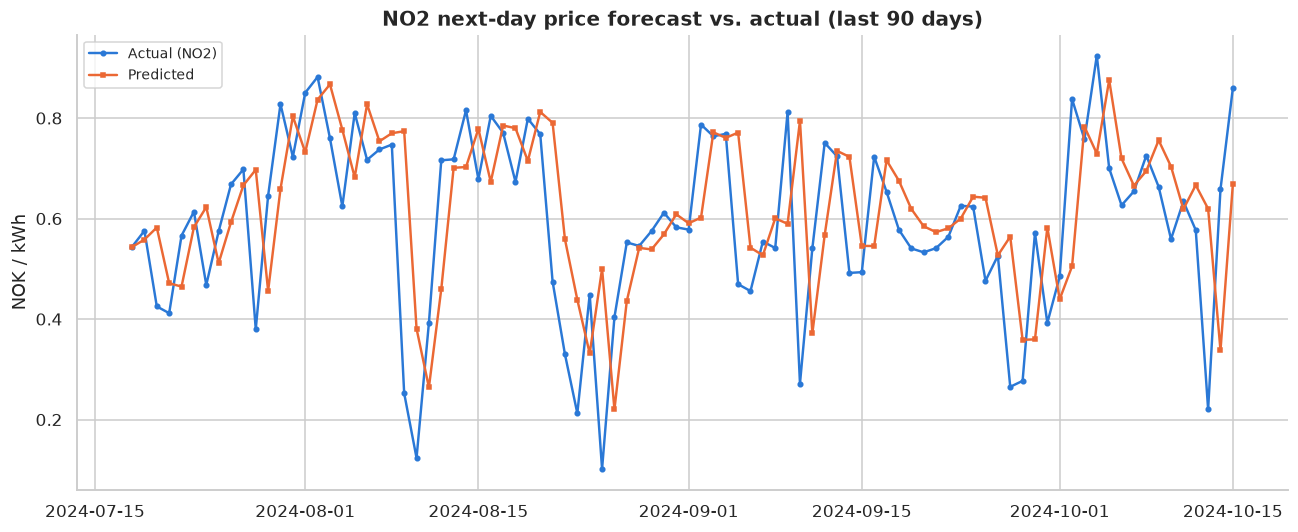

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, y_test, color=CATEGORICAL[0], linewidth=1.6, marker="o", markersize=3, label="Actual (NO2)")
ax.plot(test.index, pred, color=CATEGORICAL[1], linewidth=1.6, marker="s", markersize=3, label="Predicted")
ax.set_title(f"NO2 next-day price forecast vs. actual (last {TEST_DAYS} days)")
ax.set_ylabel("NOK / kWh")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/06_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading the result honestly:** a next-day model that only slightly beats "tomorrow will equal today" is not a
weak result here — it's the expected, correct one. Day-ahead spot prices are set by an auction that already
prices in the available public information, so a large improvement over the naive baseline would be more
suspicious than reassuring. The real value of a model like this is in longer-horizon or cross-zone forecasting
where information genuinely isn't already priced in — a natural next step for this project.


<a id="8"></a>
## 8. Key insights & recommendations

**Findings**
1. **The north/south price divide is real, large, and quantifiable** — during 2022 the south averaged several
   NOK/kWh above the north, a gap of a scale that materially affects household and business energy costs
   depending purely on which of the 5 zones you live in.
2. **NO1, NO2, and NO5 move almost as one market**; **NO4 is substantially decoupled** — confirmed by
   correlation, not just visual impression, which matters if you're building anything that treats "the Norwegian
   electricity price" as a single number.
3. **Volatility, not just price level, spiked during the crisis** — the 30-day rolling standard deviation shows
   the south wasn't just expensive in 2022, it was unpredictable, which is its own real cost for planning.
4. **Clustering days (not zones) recovers the crisis timeline from the data itself** — three regimes emerge
   without being told where the crisis started or ended, giving a defensible, data-driven answer to "when did
   this actually begin and end?"
5. **A simple next-day forecast barely beats a naive baseline — and that is the correct, honest finding** for an
   auction-priced market, not a modeling failure.

**Recommendations if this fed a real decision**
- Any national policy or subsidy scheme (like `strømstøtte` itself) that uses a **single national average price**
  is, by construction, systematically wrong for both the highest-paying south and the barely-affected north —
  the regional gap shown here is a direct, quantified case for zone-specific policy design.
- A business with flexible electricity demand (e.g. one that can shift usage across zones or time) should use the
  volatility series, not just the average price, to decide when hedging or demand-shifting is worth the effort.
- Extend the forecasting model with weather/temperature and European gas-price data as features — those are the
  variables that actually move prices beyond yesterday's value, and are the natural next step past this
  notebook's baseline.

**Skills demonstrated:** real-world time-series wrangling (long-to-wide reshaping, rolling windows), correlation
analysis, unsupervised regime detection (`KMeans` on multivariate daily observations), supervised forecasting
with lag/rolling features and an honest baseline comparison (`LinearRegression`, MAE/RMSE vs. naive persistence).
